#CA2 | BY CHRYSANTHI MOUZAKITIS 122450272

In this project all the neural networks have the task of classifying between **pictures of pancakes and pictures of french toast**. I chose these as they are similar in colour and context (ie both golden brown colour and both usually on a plate with syrup) but have differenciating attributes such as thickness or shape which the nueral network can learn. Neither of these classes are in the ImageNet list of objects with the most similar object being 'french loaf' or 'bagel'

Note: Only pictures of american style thick pancakes were used for this project. Other pancake styles such as crepes were removed and not used.

# SETTING UP THE PROJECT

First I imported everything necessary for this project, no external libraries were used outside of the ones covered in class.

In [1]:
#it may throw an error that keras_tuner is not recognised
#run the below line to fix this

In [2]:
pip install keras_tuner

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import os

from keras.preprocessing.image import load_img, img_to_array, array_to_img
from keras.preprocessing import image_dataset_from_directory

from keras import Model
from keras import Input
from keras import Sequential

from keras_tuner import Hyperband

from keras.layers import Rescaling
from keras.layers import Dense
from keras.layers import Conv2D
from keras.layers import MaxPooling2D
from keras.layers import Flatten
from keras.layers import Dropout
from keras.layers import BatchNormalization

from keras.models import load_model

from keras.optimizers import RMSprop
from keras.optimizers import Adam
from keras.optimizers import SGD

from keras.callbacks import EarlyStopping

from keras.applications import ResNet50
from keras.applications.resnet50 import preprocess_input, decode_predictions

Then I mounted the images into the google colab notebook and ensure all the folders have laoded correctly

In [4]:
import os
from google.colab import drive
drive.mount('/content/drive')
base_dir = "./drive/My Drive/AI2"
train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Then I loaded the training, validation and test set into variables to use later.


In [5]:
train_dataset = image_dataset_from_directory(directory=train_dir, label_mode="binary", color_mode='rgb', image_size=(224, 224))
val_dataset = image_dataset_from_directory(directory=val_dir, label_mode="binary", color_mode='rgb',  image_size=(224, 224))
test_dataset = image_dataset_from_directory(directory=test_dir, label_mode="binary", color_mode='rgb', image_size=(224, 224))

Found 240 files belonging to 2 classes.
Found 180 files belonging to 2 classes.
Found 180 files belonging to 2 classes.


When loading the images I used the function image_dataset_from_directory() and set the following parameters:


*   ***label_mode*** = set to binary as this task is binary classification as there are only two classes (pancake and french toast)

*   ***color_mode*** = set to rgb as the images are all in colour
*   ***image_size*** = set to 224x224, this is a smaller size than the default (255*255) as neural networks work best on smaller images. This will also make all the images the same size so the neural network can process them. The only concern here would be that because aspect ratio is not preserved, some of the images may be flattened/ squashed. However, all the images are centered around the pancake/french toast, so this should only affect the background and not the object that the neural network is classifying.



# HYPER-PARAMETER TUNING

Before creating the 1st neural network, there are a number of hyper-parameters to choose values for. These are:



*   The activation function
*   Number of layers
*   The dropout rate
*   Number of epochs
*   The batch size
*   The learning rate
*   Which optimizer to use

I will now explore each of these in turn.

***The activation function:***

 For this I will use ReLu in the hidden layers to help prevent the Vanishing Gradient problem as it is a non-saturating activation function. I will then use sigmoid in the final output layer as it is perfect for the task of binary classification as it outputs a number between 0-1 which can be interpreted as the probability the object is part of the positive class

***The number of layers:***

Although the images are only of size 224x224, they are still quite big, becuase of this I will use more layers than usual. I will do 15 total layers and then possibly reduce this number if overfitting occurs.  I will also use a Convolutional Neural Network with Max Pooling Layers in between each Convultional Layer. This is because Convultional Layers are perfect for image classification. They are computationally efficient as they have fewer parameters compared to dense networks, they are translation invariant meaning the object can be in any part of the image and still be recognised and including max pooling layers also helps make the network more general by focusing on the most important data.

***The dropout rate:***

This is a technique used to prevent overfiting in training by 'dropping' some neurons out every time according to the dropout rate. For the 1st neural network I will not use dropout as I would like to first investigate if overfitting is occuring.

***The number of epochs:***

I plan on using Early Stopping during training, this is a time effective meausre which stops the training before overfitting occurs (when the validation loss stops improving). Because of this, I will set a fixed maximum number of epochs of 30, as it is likely Early Stopping will stop before this maximum.



***The batch size:***

I will use a fixed size of 32 for the batch size throughout this project. Although I considered using Keras Tuner for the batch size, I only have limited time and resources for this project which would be depleted quickly by searching for the ideal batch size. A fixed size of 32 provides a good balance between efficient GPU usage, but also good gradient updates.

For the remaining hyperparameters (learning rate and optimiser) I will use **Keras Tuner** to find the ideal values.

## HYPER-PARAMETER TUNING WITH KERAS TUNER

I followed the instructions on the below two websites for my method of using Keras Tuner in this project.

All code inspired by https://www.geeksforgeeks.org/deep-learning/keras-tuner-for-hyperparameter-optimization/
and https://medium.com/@sanjay_dutta/hyperparameter-tuning-with-keras-tuner-and-tensorflow-48ab5ea69cc5

### Step 1: Define the model we want to build to find the hyperparameters for:



In [6]:
def build_model(hp):

    inputs =Input(shape=(224, 224, 3))
    x = Rescaling(1./255)(inputs)

    x = Conv2D(filters=128, kernel_size=(3, 3), activation="relu")(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    x = Conv2D(filters=128, kernel_size=(3, 3), activation="relu")(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    x = Conv2D(filters=64, kernel_size=(3, 3), activation="relu")(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    x = Conv2D(filters=32, kernel_size=(3, 3), activation="relu")(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    x = Conv2D(filters=32, kernel_size=(3, 3), activation="relu")(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    x = Flatten()(x)
    x = Dense(512, activation="relu")(x)
    outputs = Dense(1, activation="sigmoid")(x)

    model = Model(inputs, outputs)

    #Hyper-params to try all possible combonations of
    learningRate = hp.Choice("learning_rate", [0.001, 0.0001, 0.00001])
    optimiser = hp.Choice("optimizer", ["adam", "rmsprop", "sgd"])

    #Depending on the optimiser, do all learning rates
    if optimiser == "adam":
        optimizer = Adam(learning_rate=learningRate)

    elif optimiser == "rmsprop":
        optimizer = RMSprop(learning_rate=learningRate)

    else:
        #Stochatic Gradient Descent option
        optimizer = SGD(learning_rate=learningRate)

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


EXPLANATION OF THE ABOVE CODE:


I first added a Rescaling layer, this is to normalise the pixel values of each image to the range 0-1 for 0-255. These smaller scaled values will help improve stability and convergence as the gradients will be more consitent meaning the optimiser will take smoother steps and the network will learn and converge faster.

I then chose to do 5 Convultional Layers due to the size and complexity of the images to ensure maximum processing. This will allow the network to extract complicated features from the image such as thickness of the food which are key in the classification between pancakes and french toast as they can often appear quite similar.

I then added Max Pooling layers in between each one to reduce the size of the network. This is increasingly important as the final network has fifteen layers, so reducing the number of parameters here also reduces computation load as well as helping the model focus on the most important parts of the image.

 I also ensured that the number of filters decrease in each subsequent convultional layer so the network becomes more general as it goes forward.

 The activation function is ReLu in the hidden layers and sigmoid in the final layer for reasons explained above.

I added 3 values to attempt for the learning rate and 3 values for optimiser.

The first optimiser 'Adam' is from the example that code is inpsired by at https://medium.com/@sanjay_dutta/hyperparameter-tuning-with-keras-tuner-and-tensorflow-48ab5ea69cc5 .

The second optimiser is the one we used in class RMSProp, and the third optimiser is Stochastic Gradient Descent chosen from the list at https://towardsdatascience.com/7-tips-to-choose-the-best-optimizer-47bb9c1219e/

Each optimiser is ran with each of the possible values for the learning rate

The model is then compiled with the loss function: 'binary cross entropy' as I am doing binary classification and the metric I am recording is accuracy also due to the binary classification aspect of the task.

### Step 2 - Instantiating the Tuner from Keras Tuner

In [7]:
tuner = Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=30,
    directory='results_directory',
    project_name='the_best_results'
)

Reloading Tuner from results_directory/the_best_results/tuner0.json


I decided to use the Hyperband tuner as according to https://www.geeksforgeeks.org/deep-learning/keras-tuner-for-hyperparameter-optimization/ it 'Uses early stopping and adaptive resource allocation to speed up the search by pruning bad trials early, effectively balancing exploration and exploitation' Since this project has a time limit I decided this would be the best tuner. The code itself was taken from:  https://medium.com/@sanjay_dutta/hyperparameter-tuning-with-keras-tuner-and-tensorflow-48ab5ea69cc5 as it has an example containing Hyperband.

I maintained the maximum epochs as 30.

The model defined above is fed into the Hyperband tuner and it will try all possible combinations of optimiser with learning rate and store the results in results_directory/the_best_results

### Step 3 - Finding the Best Results

In [8]:
tuner.search(train_dataset, epochs=30, validation_data=val_dataset)
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

The search is then carried out with the tuner, with epochs also set to 30, and the validation data for it to find the hyperparameters that score the best.

In [9]:
print(f"Best Optimizer: {best_hps.get('optimizer')}")
print(f"Best learning rate: {best_hps.get('learning_rate')}")

Best Optimizer: rmsprop
Best learning rate: 0.0001


Here it has returned that 'Adam' is the best optimiser with the best learning rate of '0.0001'

Now that I have defined values for all the hyperparameters, I now will make the 1st neural network and test it.

# Creating the 1st Neural Network and Testing it

As I already compiled the model above, I can simply build the best model from above

In [10]:
model = tuner.hypermodel.build(best_hps)

I will now fit the model on the entirety of the development data, with epochs set to 30, batch size set to 32, using earlystopping and a patience of 2.

In [11]:
model_history = model.fit(train_dataset, epochs=30, batch_size=32,
            verbose=0, validation_data=val_dataset,
            callbacks=[EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)])

<Axes: >

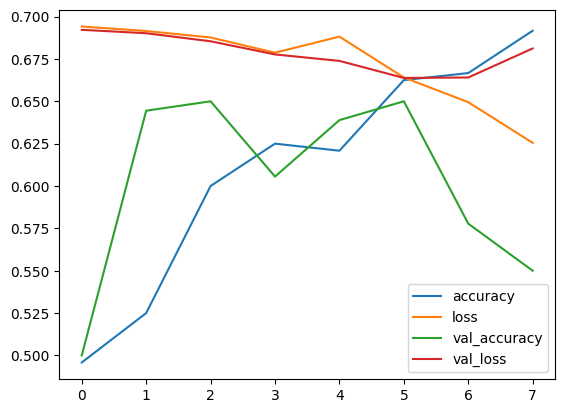

In [12]:
pd.DataFrame(model_history.history).plot()

In [13]:
test_loss, test_acc = model.evaluate(test_dataset)
test_acc

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 138ms/step - accuracy: 0.6834 - loss: 0.6512


0.6611111164093018

As seen from the above graph that there is some slight overfitting happening.
This can be seen by the high training accuracy, but the varying validation accuracy. It signifies that the model is simply memorising training examples, not generalising to unseen data. The final accuracy rate on the test set is also low and can be improved.

# CREATING A NEW MODEL WITH OVERFITTING SOLUTIONS

I will now make the second neural network of this project, closely mirroring the first one above, but with several overfitting solutions to help increase the accuracy.

I will:

*   Reduce the size of the network by reducing the number of layers
*   Add Batch Normalisation Layers to act as a regulariser
*   Add Dropout Layers to also reduce the size of the network



I will assume the optimiser of Adam and the learning rate of 0.0001 still apply as the best choices here

In [14]:
inputs = Input(shape=(224, 224, 3))
x = Rescaling(scale=1./255)(inputs)
x = Conv2D(filters=128, kernel_size=(3, 3), activation="relu")(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = BatchNormalization()(x)
x = Conv2D(filters=64, kernel_size=(3, 3), activation="relu")(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Dropout(0.1)(x)
x = Conv2D(filters=32, kernel_size=(3, 3), activation="relu")(x)
x = Flatten()(x)
outputs = Dense(1, activation="sigmoid")(x)
convnet_num2 = Model(inputs, outputs)
convnet_num2.compile(optimizer=Adam(learning_rate=0.0001), loss="binary_crossentropy", metrics=["accuracy"])

In [15]:
ans2 = convnet_num2.fit(train_dataset, epochs=30, batch_size=32,
            verbose=0, validation_data = val_dataset,
            callbacks=[EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)])

<Axes: >

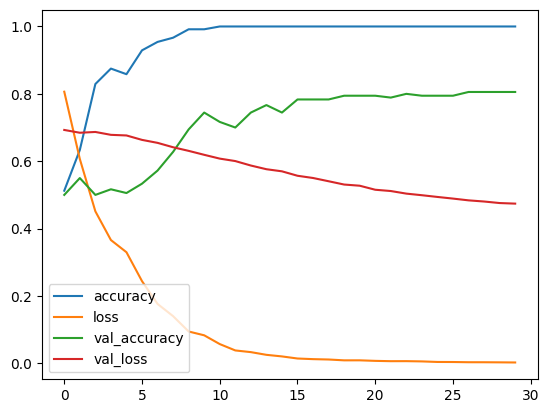

In [16]:
pd.DataFrame(ans2.history).plot()

In [17]:
test_loss, test_acc = convnet_num2.evaluate(test_dataset)
test_acc

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - accuracy: 0.7166 - loss: 0.5550


0.7277777791023254

Here we can observe a slight improvement! This shows that the overfitting solutions worked, however, the final accuracy rate is not very high so I will try a different approach.

Because the above neural networks are only trained on very few images, with a total training dataset of 500 images, they will never be ever to generalise to unseen examples very well. Because of this, I will use transfer learning. I will be able to use a pretrained base for my network, one that was trained on a very large and represenatative database of images.

# 3rd & 4th Neural Networks - Transfer Learning

For my third neural network I will change the approach slightly by using transfer learning. I will use the Resnet base which has been trained on the ImageNet collection of objects for this transfer learning. This is perfect as neither pancakes or french toast are in the ImageNet collection, but similar objects such as 'French loaf', 'bagel' and even related objects such as 'Frying pan' are within the collection.

I will trial two versions of this neural network:

*   The 1st will have the ResNet base and 1 singular dense layer after it.

*   The 2nd will have the ResNet base and then 3 layers after it.

This is to investigate if further layers after the ResNet base improve accuracy by making the network more tuned to my task of categorsing pancakes and french toast.

For both neural networks I will first freeze the resnet base's weights, train the neural network, then unfreeze the weights and train further. The second round of training will have a lower learning rate as to not disturb the pretrained weights too greatly.

They will both use the same hyperparameters values as above where applicable.

In [18]:
#Transfer Learning NN 1 - Only dense final layer

resnet50_base = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
inputs = Input(shape=(224, 224, 3))
x = preprocess_input(inputs)
x = resnet50_base(x)

x = Flatten()(x)
outputs = Dense(1, activation="sigmoid")(x)
transfer_one = Model(inputs=inputs, outputs=outputs)

resnet50_base.trainable = False

transfer_one.compile(optimizer=Adam(learning_rate=0.0001), loss="binary_crossentropy", metrics=["accuracy"])

transfer_one_history = transfer_one.fit(train_dataset, epochs=30,
                validation_data=val_dataset,
                callbacks=[EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)],
                verbose=0)

In the above code you can see the import of the resnet base and a small dense layer of size 1 on top of it. I maintained sigmoid as the output function so it would output the probability of the object being part of the positive class.

Adam is the optimiser as that is what I used in the previous neural networks, along with the learning rate of 0.0001. Similarily the epochs are set to 30 and the patience is set to 2. This is so I can fairly compare the results of this neural network and the one from before.

In [19]:
#unfreeze weights and contune training with smaller learning rate

for layer in resnet50_base.layers:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True

transfer_one.compile(optimizer=Adam(learning_rate=0.00001), loss="binary_crossentropy", metrics=["accuracy"])

transfer_one_history = transfer_one.fit(train_dataset, epochs=30,
              validation_data=val_dataset,
              callbacks=[EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)],
              verbose=0)

Above, the weights are unfrozen ensuring that any Batch Normalisation layers are still frozen.

The learning rate is reduced from 0.0001 to 0.00001 to slow the learning as to not greatly change the learned weights of the resent base.

Training is continued

<Axes: >

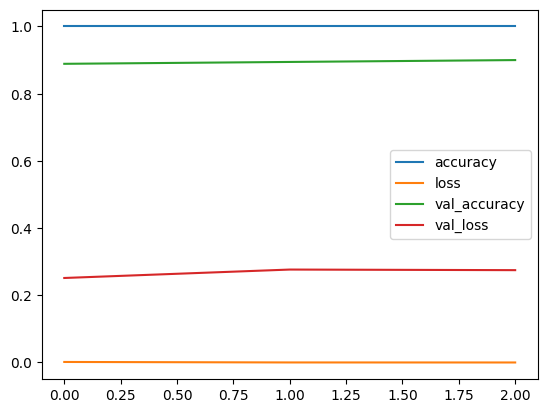

In [20]:
pd.DataFrame(transfer_one_history.history).plot()

In [21]:
# The convnet that was trained and tuned using transfer learning
test_loss, test_acc = transfer_one.evaluate(test_dataset)
test_acc

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step - accuracy: 0.9287 - loss: 0.2595


0.9333333373069763

Here we can see a high accuracy and low loss as expected from transfer learning!

The accuracy is greatly higher than the neural networks without transfer learning also. This is due to the fact that the resnet base was trained on a large dataset and my own above was trained on only 300 images of each class.

For the 2nd neural network I attempted using the following architecture:

*   Resnetbase
*   Convulutional Layer
*   MaxPooling Layer
*   Dense Output Layer

but this did not increase accuracy, it instead decreased as is shown below:

<Axes: >

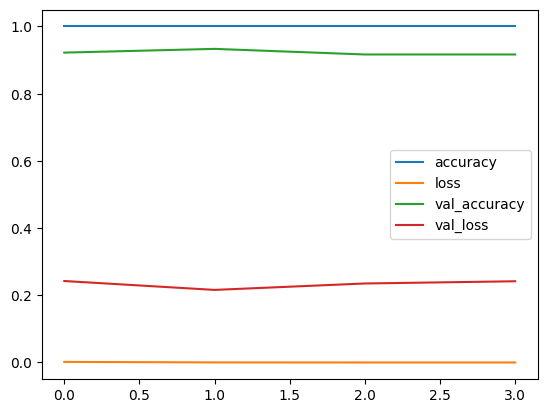

In [22]:
#Transfer Learning NN 2 - + Convulutional Layers

resnet50_base = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
inputs = Input(shape=(224, 224, 3))
x = preprocess_input(inputs)
x = resnet50_base(x)
x = Conv2D(filters=64, kernel_size=(3, 3), activation="relu")(x)
x = MaxPooling2D(pool_size=(2, 2))(x)

x = Flatten()(x)
outputs = Dense(1, activation="sigmoid")(x)
transfer_two = Model(inputs=inputs, outputs=outputs)

resnet50_base.trainable = False

transfer_two.compile(optimizer=Adam(learning_rate=0.0001), loss="binary_crossentropy", metrics=["accuracy"])

transfer_two_history = transfer_two.fit(train_dataset, epochs=30,
                validation_data=val_dataset,
                callbacks=[EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)],
                verbose=0)

#unfreeze weights and contune traing with smaller learning rate

for layer in resnet50_base.layers:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True

transfer_two.compile(optimizer=Adam(learning_rate=0.00001), loss="binary_crossentropy", metrics=["accuracy"])

transfer_two_history = transfer_two.fit(train_dataset, epochs=30,
              validation_data=val_dataset,
              callbacks=[EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)],
              verbose=0)

pd.DataFrame(transfer_two_history.history).plot()

In [23]:
test_loss, test_acc = transfer_two.evaluate(test_dataset)
test_acc

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step - accuracy: 0.9221 - loss: 0.2178


0.9277777671813965

This is worse, so I instead created a version with only Dense layers, this proved much more succesful:

<Axes: >

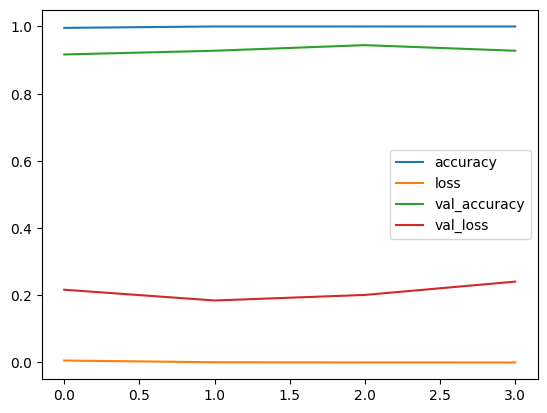

In [24]:
#Transfer Learning NN 2 - Dense Layers Only

resnet50_base = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
inputs = Input(shape=(224, 224, 3))
x = preprocess_input(inputs)
x = resnet50_base(x)

x = Flatten()(x)
outputs = Dense(20, activation="relu")(x)
outputs = Dense(10, activation="relu")(x)
outputs = Dense(1, activation="sigmoid")(x)
transfer_three = Model(inputs=inputs, outputs=outputs)

resnet50_base.trainable = False

transfer_three.compile(optimizer=Adam(learning_rate=0.0001), loss="binary_crossentropy", metrics=["accuracy"])

transfer_three_history = transfer_three.fit(train_dataset, epochs=30,
                validation_data=val_dataset,
                callbacks=[EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)],
                verbose=0)

#unfreeze weights and contune traing with smaller learning rate

for layer in resnet50_base.layers:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True

transfer_three.compile(optimizer=Adam(learning_rate=0.00001), loss="binary_crossentropy", metrics=["accuracy"])

transfer_three_history = transfer_three.fit(train_dataset, epochs=30,
              validation_data=val_dataset,
              callbacks=[EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)],
              verbose=0)

pd.DataFrame(transfer_three_history.history).plot()

In [25]:
test_loss, test_acc = transfer_three.evaluate(test_dataset)
test_acc

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 136ms/step - accuracy: 0.9316 - loss: 0.1962


0.9277777671813965

Finally I wanted to take my most successful neural network so far and try and improve it as much as possible. This was of course the one with the resnet base and one singular dense output layer. I noticed that although the validation accuracy is very high, it hits a plateau. This is a sign of slight overfitting. I decided to apply some overfitting solutions to try and improve this accuracy even further.

I added:

*   Dropout : with a high rate of 0.3
*   BatchNormalisation Layer : after the resnet base
*   Lower learning rate for further learning to 0.00001

<Axes: >

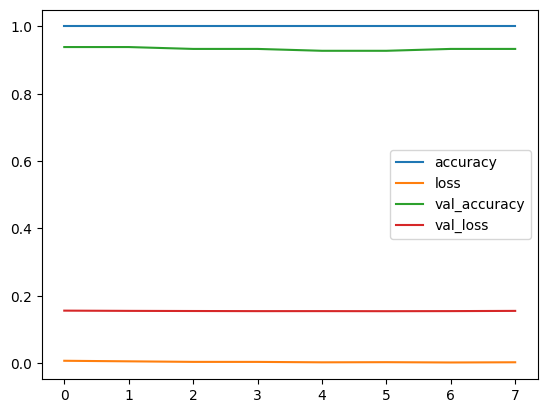

In [26]:
#Transfer Learning NN 2 - + Convulutional Layers

resnet50_base = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
inputs = Input(shape=(224, 224, 3))
x = preprocess_input(inputs)
x = resnet50_base(x)
x = BatchNormalization()(x)
x = Flatten()(x)
x = Dropout(0.3)(x)
outputs = Dense(1, activation="sigmoid")(x)
transfer_four = Model(inputs=inputs, outputs=outputs)

resnet50_base.trainable = False

transfer_four.compile(optimizer=Adam(learning_rate=0.0001), loss="binary_crossentropy", metrics=["accuracy"])

transfer_four_history = transfer_four.fit(train_dataset, epochs=30,
                validation_data=val_dataset,
                callbacks=[EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)],
                verbose=0)

#unfreeze weights and contune traing with smaller learning rate

for layer in resnet50_base.layers:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True

transfer_four.compile(optimizer=Adam(learning_rate=0.000001), loss="binary_crossentropy", metrics=["accuracy"])

transfer_four_history = transfer_four.fit(train_dataset, epochs=30,
              validation_data=val_dataset,
              callbacks=[EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)],
              verbose=0)

pd.DataFrame(transfer_four_history.history).plot()

In [27]:
test_loss, test_acc = transfer_four.evaluate(test_dataset)
test_acc

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 135ms/step - accuracy: 0.9405 - loss: 0.1540


0.9388889074325562

This was successful! With the highest accuracy so far.

# FINAL STEPS

In conclusion, the neural networks without transfer learning improved with some overfitting prevention techniques, but never reached the levels of accuracy as the neural networks with transfer learning. Therefore, my best model was the neural network with the one singular Dense layer after the resnet base, with overfitting solutions applied.

I will now save this final version to use to test!

In [28]:
transfer_four.save(os.path.join(base_dir, "best_network.keras"))